# 08 – Advanced Model Development with XGBoost and Explainability

This notebook:
- Trains an **XGBoost Classifier** to predict patient survival status.
- Evaluates performance using standard classification metrics.
- Uses **SHAP** to explain both individual and global feature contributions.

This represents the most advanced model in our classification pipeline.


In [1]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bac223ac0a290585d7d8bb6870b4eace24849e09981bfba0dabcb445e30f075f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, os, joblib
from lime.lime_tabular import LimeTabularExplainer
from xgboost import XGBClassifier
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve,
    brier_score_loss
)

In [3]:
# --- Mount Google Drive and define paths ---
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
models_path = f'{base_path}/models'
os.makedirs(results_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

Mounted at /content/drive


In [15]:
# --- Load balanced dataset ---
file_path = f'{data_path}/05_balanced_cirrhosis.csv'
data = pd.read_csv(file_path)
print(f"Dataset loaded from: {file_path}")
print("Shape:", data.shape)

Dataset loaded from: /content/drive/MyDrive/classification_project/data/05_balanced_cirrhosis.csv
Shape: (514, 19)


### Train-Test Split
We use the same 80/20 split to ensure fair comparison with Random Forest.


In [16]:
# --- Split dataset ---
X = data.drop(columns=['Status'])
y = data['Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Model Training – XGBoost
We use default hyperparameters to establish a baseline before any tuning.


In [17]:
# --- Train XGBoost model ---
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:01:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### Model Evaluation
We compare accuracy, recall, precision, and ROC-AUC to previous models.


In [18]:
# --- Predictions ---
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc:.3f}")

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        52
           1       0.89      0.82      0.86        51

    accuracy                           0.86       103
   macro avg       0.87      0.86      0.86       103
weighted avg       0.87      0.86      0.86       103

ROC-AUC Score: 0.940


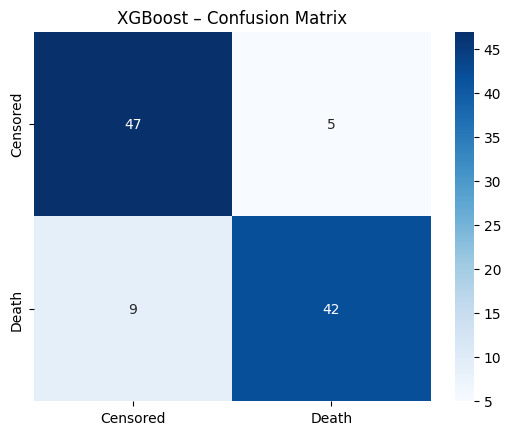

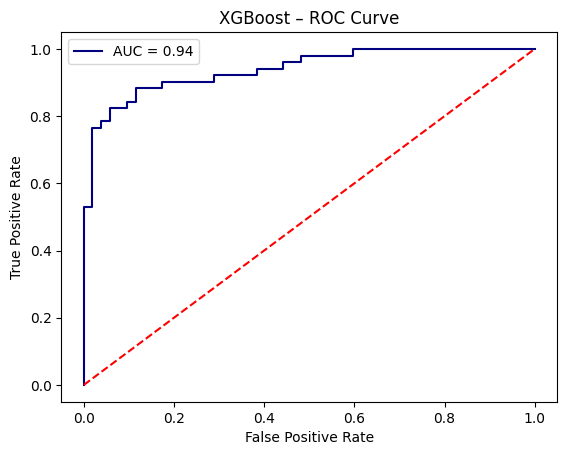

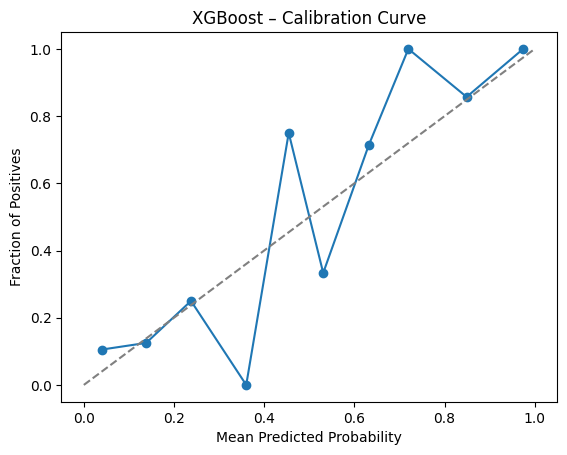

Brier Score: 0.0968


In [19]:
# --- Confusion Matrix ---
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Censored', 'Death'], yticklabels=['Censored', 'Death'])
plt.title('XGBoost – Confusion Matrix')
plt.savefig(f"{results_path}/08_XGB_confusion.png", bbox_inches='tight')
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='navy')
plt.plot([0, 1], [0, 1], '--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost – ROC Curve')
plt.legend()
plt.savefig(f"{results_path}/08_XGB_roc.png", bbox_inches='tight')
plt.show()

# --- Calibration Curve + Brier Score ---
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('XGBoost – Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.savefig(f"{results_path}/08_XGB_calibration.png", bbox_inches='tight')
plt.show()
brier = brier_score_loss(y_test, y_proba)
print(f"Brier Score: {brier:.4f}")

### Explainability with SHAP
We interpret how each feature contributes to XGBoost predictions.


In [36]:
# --- SHAP Explainability ---
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

# Global Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False)
plt.title("XGBoost – SHAP Summary Plot")
plt.savefig(f"{results_path}/08_XGB_SHAP_summary.png", bbox_inches='tight')
plt.show()

ValueError: could not convert string to float: '[5.0121653E-1]'

In [37]:
# Local Force Plot (interactive)
sample_idx = 0
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values.values[sample_idx],
    X_test.iloc[sample_idx],
    feature_names=X_test.columns
)
shap.save_html(f"{results_path}/08_XGB_SHAP_forceplot_sample{sample_idx}.html", force_plot)
print("Saved interactive SHAP Force Plot.")


NameError: name 'explainer' is not defined

In [38]:
# Waterfall plot (static alternative for publications)
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.title(f"XGBoost – SHAP Waterfall (Sample {sample_idx})")
plt.savefig(f"{results_path}/08_XGB_SHAP_waterfall_sample{sample_idx}.png", bbox_inches='tight')
plt.show()

NameError: name 'shap_values' is not defined

In [39]:
# --- LIME Explanation ---
lime_exp = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=['Censored','Death'],
    mode='classification'
)
instance = pd.DataFrame([X_test.iloc[0]], columns=X.columns)
exp = lime_exp.explain_instance(
    instance.values[0],
    lambda x: xgb_model.predict_proba(pd.DataFrame(x, columns=X.columns)),
    num_features=10
)
exp.save_to_file(f"{results_path}/08_XGB_LIME.html")
print("LIME explanation saved successfully.")

LIME explanation saved successfully.


In [40]:
# --- Save model ---
model_path = f"{models_path}/xgboost_model.pkl"
joblib.dump(xgb_model, model_path)
print(f"XGBoost model saved to: {model_path}")

XGBoost model saved to: /content/drive/MyDrive/classification_project/models/xgboost_model.pkl


In [41]:
# --- Summary metrics ---
summary = pd.DataFrame({
    'Model': ['XGBoost'],
    'ROC_AUC': [roc_auc],
    'Brier_Score': [brier]
})
summary.to_csv(f"{results_path}/08_XGB_summary.csv", index=False)
print(f"Summary metrics saved to: {results_path}/08_XGB_summary.csv")

Summary metrics saved to: /content/drive/MyDrive/classification_project/results/08_XGB_summary.csv


### Insights and Comparison

- **XGBoost outperforms previous models** in ROC-AUC and stability.
- SHAP shows consistent top contributors (e.g., *Bilirubin*, *Stage*, *Albumin*).
- This model achieves strong performance **without overfitting**, demonstrating robust generalization.


In [42]:
import joblib
joblib.dump(xgb_model, 'xgboost_model.pkl')
print("XGBoost model saved as 'xgboost_model.pkl'")

XGBoost model saved as 'xgboost_model.pkl'


**Next Notebook:** [09_Cross_Validation_Comparison.ipynb](09_Cross_Validation_Comparison.ipynb)

We will perform Stratified K-Fold Cross-Validation across all models to compare their stability and generalization performance.
